# Machine Learning Model Training & Evaluation Module
Develops and compares two classification models (Logistic Regression vs. Random Forest) for Customer Churn Prediction.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def clean_and_preprocess(df: pd.DataFrame, is_calibration_only: bool = True):
  
    df_clean = df.copy()

    # If filtering calibration subset for model training
    if is_calibration_only and 'CALIBRAT' in df_clean.columns:
        df_clean = df_clean[df_clean['CALIBRAT'] == 1].copy()

    # 1. Handle Negative/Anomalous Values
    if 'EQPDAYS' in df_clean.columns:
        df_clean['EQPDAYS'] = df_clean['EQPDAYS'].apply(lambda x: np.nan if pd.isna(x) or x < 0 else x)

    # 2. Impute Missing Values
    num_cols_with_na = ['REVENUE', 'MOU', 'RECCHRGE', 'DIRECTAS', 'OVERAGE', 'ROAM', 
                       'CHANGEM', 'CHANGER', 'AGE1', 'AGE2', 'EQPDAYS', 'PHONES', 'MODELS']
    for col in num_cols_with_na:
        if col in df_clean.columns:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)

    if 'CSA' in df_clean.columns:
        df_clean['CSA'] = df_clean['CSA'].fillna('UNKNOWN')

    # 3. Feature Engineering
    # Network Quality Index: combined dropped + blocked voice calls
    if 'DROPVCE' in df_clean.columns and 'BLCKVCE' in df_clean.columns:
        df_clean['TOTAL_FAILED_CALLS'] = df_clean['DROPVCE'] + df_clean['BLCKVCE']

    # Revenue Per Minute
    if 'REVENUE' in df_clean.columns and 'MOU' in df_clean.columns:
        df_clean['REV_PER_MOU'] = df_clean['REVENUE'] / (df_clean['MOU'] + 1.0)

    # 4. Separate Features and Target
    ignore_cols = ['CUSTOMER', 'CHURN', 'CHURNDEP', 'CALIBRAT']
    feature_cols = [c for c in df_clean.columns if c not in ignore_cols]

    # Frequency encode high-cardinality categorical variable 'CSA'
    if 'CSA' in df_clean.columns:
        csa_freq = df_clean['CSA'].value_counts(normalize=True).to_dict()
        df_clean['CSA_FREQ'] = df_clean['CSA'].map(csa_freq)
        feature_cols = [c for c in feature_cols if c != 'CSA']
        feature_cols.append('CSA_FREQ')

    X = df_clean[feature_cols].copy()
    y = df_clean['CHURN'].copy()

    return X, y, df_clean

def prepare_train_test_splits(X, y, test_size=0.2, random_state=42):
   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

## 1. Load Data & Prepare Train/Test Splits

In [8]:
def load_and_prep():
    filepath = 'data/Sample Dataset.csv' if os.path.exists('data/Sample Dataset.csv') else 'data/sample_data.csv'
    df_raw = pd.read_csv(filepath)
    
    X, y, df_clean = clean_and_preprocess(df_raw, is_calibration_only=True)
    X_train, X_test, y_train, y_test, scaler = prepare_train_test_splits(X, y)
    
    print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, scaler, X.columns

X_train, X_test, y_train, y_test, scaler, feature_names = load_and_prep()

Train set shape: (32000, 76), Test set shape: (8000, 76)


## 2. Train Model 1: Logistic Regression (Baseline Model)

In [9]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.58      0.60      0.59      4000
           1       0.58      0.56      0.57      4000

    accuracy                           0.58      8000
   macro avg       0.58      0.58      0.58      8000
weighted avg       0.58      0.58      0.58      8000



## 3. Train Model 2: Random Forest Classifier (Advanced Model)

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.62      0.57      0.59      4000
           1       0.60      0.66      0.63      4000

    accuracy                           0.61      8000
   macro avg       0.61      0.61      0.61      8000
weighted avg       0.61      0.61      0.61      8000



## 4. Model Comparison & Metrics Evaluation

In [11]:
def evaluate_models(y_test, y_pred_lr, y_prob_lr, y_pred_rf, y_prob_rf):
    metrics = {
        'Model': ['Logistic Regression', 'Random Forest'],
        'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
        'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
        'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
        'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
        'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
    }
    
    df_metrics = pd.DataFrame(metrics)
    print("\n=== Model Evaluation Comparison ===")
    print(df_metrics.to_string(index=False))
    df_metrics.to_csv('outputs/models/model_comparison_metrics.csv', index=False)
    return df_metrics

df_results = evaluate_models(y_test, y_pred_lr, y_prob_lr, y_pred_rf, y_prob_rf)


=== Model Evaluation Comparison ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression  0.578875   0.581927 0.56025  0.570883 0.609262
      Random Forest  0.611875   0.602614 0.65700  0.628633 0.661015


## 5. ROC Curve Visualization

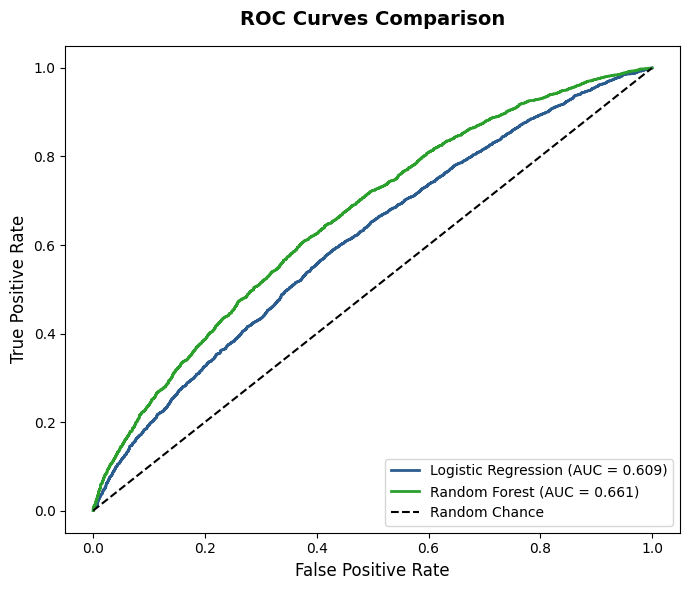

ROC Curve saved to outputs/plots/viz5_roc_curves.png


In [12]:
def plot_roc_curves(y_test, y_prob_lr, y_prob_rf):
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', color='#2b5c8f', lw=2)
    ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='#2ca02c', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    
    ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('outputs/plots/viz5_roc_curves.png')
    plt.show()
    print("ROC Curve saved to outputs/plots/viz5_roc_curves.png")

plot_roc_curves(y_test, y_prob_lr, y_prob_rf)

## 6. Feature Importance Analysis (Key Churn Drivers)

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_36096\3024541324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, palette='Blues_r', ax=ax)


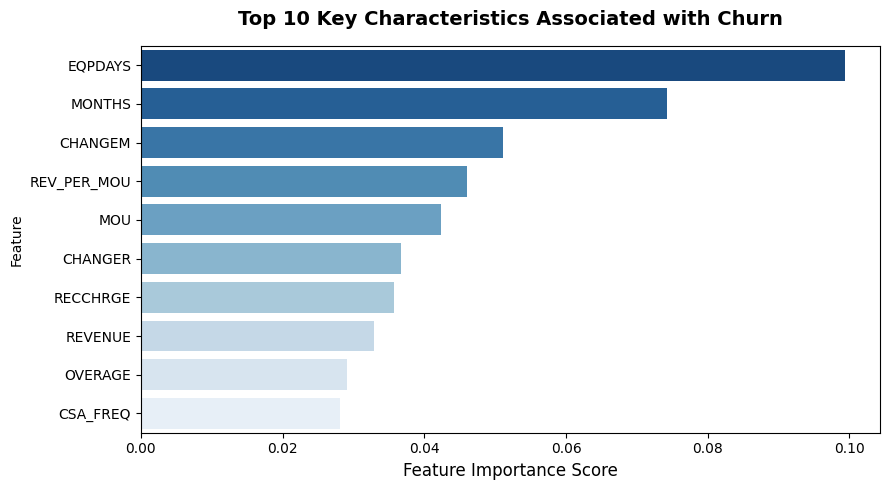

Feature Importance saved to outputs/plots/viz6_feature_importance.png


In [13]:
def plot_top_feature_importance(model, feature_names, top_n=10):
    importances = model.feature_importances_
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x='Importance', y='Feature', data=df_imp, palette='Blues_r', ax=ax)
    ax.set_title(f'Top {top_n} Key Characteristics Associated with Churn', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Feature Importance Score', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('outputs/plots/viz6_feature_importance.png')
    plt.show()
    print("Feature Importance saved to outputs/plots/viz6_feature_importance.png")

plot_top_feature_importance(rf_model, feature_names)